In [6]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = '../examples/comparisons/diiid_3_coil'
SWEEPS = {'convergence_w5_b_temp': 'Bayesian', 'convergence_w5_l_temp': 'Multi-start L-BFGS'}
N_COILS = 3
CFG_RE = re.compile(r'alpha:[^,]+,weight:([^,]+),lambda:([^,]+),coils:(\d+)')

In [7]:
def load_sweep(sweep, method, n_coils):
    rows = []
    sweep_dir = os.path.join(BASE, sweep)
    for cfg in sorted(os.listdir(sweep_dir)):
        m = CFG_RE.match(cfg)
        if not m:
            continue
        weight, lam, coils = float(m.group(1)), float(m.group(2)), int(m.group(3))
        if coils != n_coils:
            continue
        cfg_dir = os.path.join(sweep_dir, cfg)
        for run in sorted(os.listdir(cfg_dir)):
            rpath = os.path.join(cfg_dir, run, 'results.json')
            if not os.path.exists(rpath):
                rpath = os.path.join(cfg_dir, run, 'checkpoint.json')
            if not os.path.exists(rpath):
                continue
            d = json.load(open(rpath))
            inner = d.get('methods', {}).get(method)
            if inner is None:
                continue
            I = np.abs(np.array(inner.get('coil_currents', [])))
            if I.size == 0:
                continue
            rows.append({
                'sweep': sweep,
                'method': method,
                'weight_fb': weight,
                'lambda': lam,
                'num_coils': coils,
                'total_current': float(I.sum()),
                'max_current': float(I.max()),
                'l2_current': float(np.sqrt((I**2).sum())),
                'best_flux_err': inner.get('best_flux_err', float('nan')),
                'best_fb_cost': inner.get('best_fb_cost', float('nan')),
                'best_cost': inner.get('best_cost', float('nan')),
            })
    return rows

all_rows = []
for sweep, method in SWEEPS.items():
    all_rows += load_sweep(sweep, method, N_COILS)

df = pd.DataFrame(all_rows).sort_values(['method', 'weight_fb']).reset_index(drop=True)
print(f'rows={len(df)}')
df

rows=8


,sweep,method,weight_fb,lambda,num_coils,total_current,max_current,l2_current,best_flux_err,best_fb_cost,best_cost
0,convergence_w5_b_temp,Bayesian,0.0001,0.000001,3,72760.112459,21322.178723,32331.480375,0.001348,0.000049,0.009595
1,convergence_w5_b_temp,Bayesian,0.0010,0.000001,3,126837.077072,43254.759401,60327.514683,0.004238,0.000063,0.012461
2,convergence_w5_b_temp,Bayesian,0.0100,0.000001,3,132576.435406,46597.832954,66980.561745,0.008172,0.000804,0.219289
3,convergence_w5_b_temp,Bayesian,0.1000,0.000001,3,201322.410407,57661.754589,93201.296607,0.011250,0.000497,0.172072
4,convergence_w5_l_temp,Multi-start L-BFGS,0.0001,0.000001,3,134363.253610,51720.880116,68041.602521,0.019928,0.000793,0.027534
5,convergence_w5_l_temp,Multi-start L-BFGS,0.0010,0.000001,3,134363.159952,51720.863609,68041.566712,0.019928,0.000794,0.028011
6,convergence_w5_l_temp,Multi-start L-BFGS,0.0100,0.000001,3,134363.252717,51720.879965,68041.602184,0.019928,0.000925,0.042089
7,convergence_w5_l_temp,Multi-start L-BFGS,0.1000,0.000001,3,167270.664735,35528.797075,70198.665591,0.015277,0.002859,0.087026


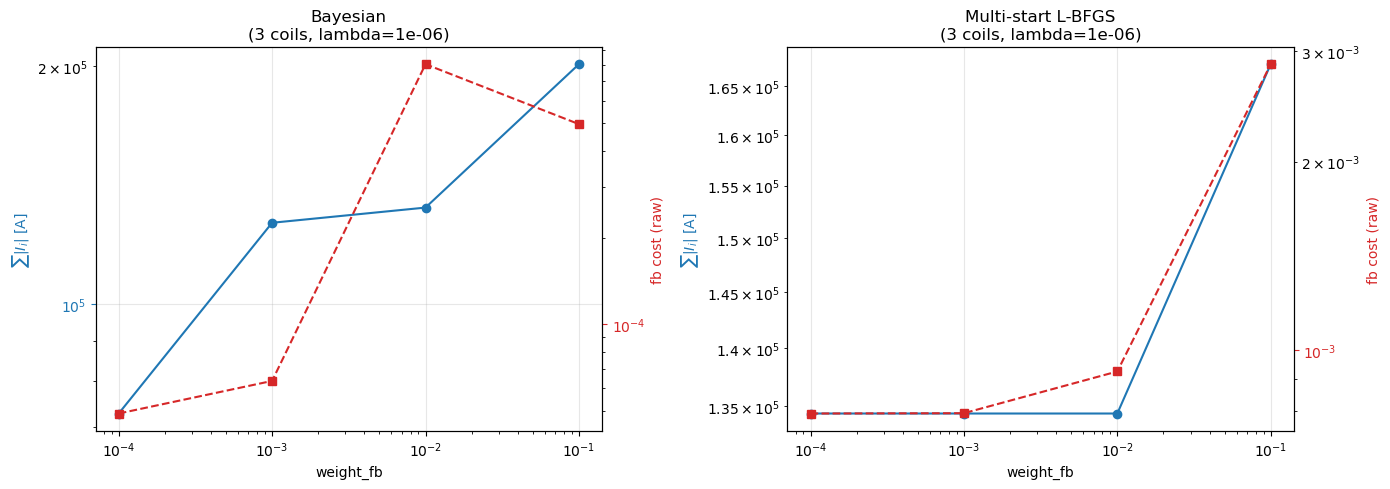

In [8]:
RIGHT_METRIC = 'best_fb_cost'
RIGHT_LABEL = 'fb cost (raw)'
RIGHT_LOG = True

methods = list(SWEEPS.values())
fig, axes = plt.subplots(1, len(methods), figsize=(7 * len(methods), 5), squeeze=False)
for ax1, method in zip(axes[0], methods):
    sub = df[df['method'] == method].sort_values('weight_fb')
    ax2 = ax1.twinx()
    ax1.plot(sub['weight_fb'], sub['total_current'], 'o-', color='tab:blue', lw=1.5, ms=6)
    ax2.plot(sub['weight_fb'], sub[RIGHT_METRIC], 's--', color='tab:red', lw=1.5, ms=6)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    if RIGHT_LOG:
        ax2.set_yscale('log')
    ax1.set_xlabel('weight_fb')
    ax1.set_ylabel(r'$\sum|I_i|$ [A]', color='tab:blue')
    ax2.set_ylabel(RIGHT_LABEL, color='tab:red')
    ax1.tick_params(axis='y', colors='tab:blue')
    ax2.tick_params(axis='y', colors='tab:red')
    lam_str = f'{sub["lambda"].iloc[0]:.0e}' if len(sub) else 'n/a'
    ax1.set_title(f'{method}\n({N_COILS} coils, lambda={lam_str})')
    ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
def load_sweep_all_coils(sweep, method):
    rows = []
    sweep_dir = os.path.join(BASE, sweep)
    for cfg in sorted(os.listdir(sweep_dir)):
        m = CFG_RE.match(cfg)
        if not m:
            continue
        weight, lam, coils = float(m.group(1)), float(m.group(2)), int(m.group(3))
        cfg_dir = os.path.join(sweep_dir, cfg)
        for run in sorted(os.listdir(cfg_dir)):
            rpath = os.path.join(cfg_dir, run, 'results.json')
            if not os.path.exists(rpath):
                rpath = os.path.join(cfg_dir, run, 'checkpoint.json')
            if not os.path.exists(rpath):
                continue
            d = json.load(open(rpath))
            inner = d.get('methods', {}).get(method)
            if inner is None:
                continue
            I = np.abs(np.array(inner.get('coil_currents', [])))
            if I.size == 0:
                continue
            rows.append({
                'sweep': sweep,
                'method': method,
                'weight_fb': weight,
                'lambda': lam,
                'num_coils': coils,
                'total_current': float(I.sum()),
                'max_current': float(I.max()),
                'l2_current': float(np.sqrt((I**2).sum())),
                'best_flux_err': inner.get('best_flux_err', float('nan')),
                'best_fb_cost': inner.get('best_fb_cost', float('nan')),
                'best_cost': inner.get('best_cost', float('nan')),
            })
    return rows

all_rows_full = []
for sweep, method in SWEEPS.items():
    all_rows_full += load_sweep_all_coils(sweep, method)
df_full = pd.DataFrame(all_rows_full).sort_values(['method', 'num_coils', 'weight_fb']).reset_index(drop=True)
print(f'rows={len(df_full)}')
df_full

rows=32


,sweep,method,weight_fb,lambda,num_coils,total_current,max_current,l2_current,best_flux_err,best_fb_cost,best_cost
0,convergence_w5_b_temp,Bayesian,0.0001,0.000001,2,60904.784275,29366.683694,35344.093168,0.004181,0.000381,1.263988e-02
1,convergence_w5_b_temp,Bayesian,0.0010,0.000001,2,100156.990323,34917.426991,51980.078754,0.014935,0.002043,6.772797e-02
2,convergence_w5_b_temp,Bayesian,0.0100,0.000001,2,72190.779464,32336.367494,40441.791461,0.005001,0.000461,1.528170e-02
3,convergence_w5_b_temp,Bayesian,0.1000,0.000001,2,54883.575731,26240.480992,31820.915138,0.004492,0.000654,2.180860e-02
4,convergence_w5_b_temp,Bayesian,0.0001,0.000001,3,72760.112459,21322.178723,32331.480375,0.001348,0.000049,9.594904e-03
5,convergence_w5_b_temp,Bayesian,0.0010,0.000001,3,126837.077072,43254.759401,60327.514683,0.004238,0.000063,1.246073e-02
6,convergence_w5_b_temp,Bayesian,0.0100,0.000001,3,132576.435406,46597.832954,66980.561745,0.008172,0.000804,2.192888e-01
7,convergence_w5_b_temp,Bayesian,0.1000,0.000001,3,201322.410407,57661.754589,93201.296607,0.011250,0.000497,1.720721e-01
8,convergence_w5_b_temp,Bayesian,0.0001,0.000001,4,88482.437724,17745.581773,33216.512165,0.001498,0.000050,8.990795e-02
9,convergence_w5_b_temp,Bayesian,0.0010,0.000001,4,67352.827888,18634.075026,28985.964345,0.002067,0.000295,5.305889e-01


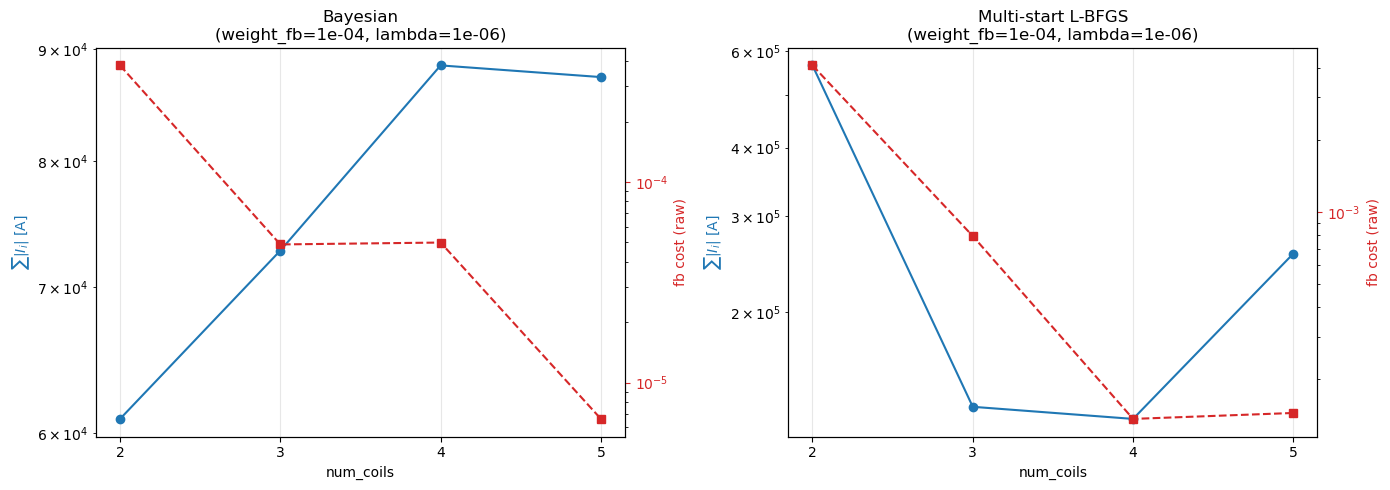

In [11]:
FIXED_WEIGHT = 1e-04
RIGHT_METRIC = 'best_fb_cost'
RIGHT_LABEL = 'fb cost (raw)'
RIGHT_LOG = True

methods = list(SWEEPS.values())
fig, axes = plt.subplots(1, len(methods), figsize=(7 * len(methods), 5), squeeze=False)
for ax1, method in zip(axes[0], methods):
    sub = df_full[(df_full['method'] == method) & (np.isclose(df_full['weight_fb'], FIXED_WEIGHT))].sort_values('num_coils')
    ax2 = ax1.twinx()
    ax1.plot(sub['num_coils'], sub['total_current'], 'o-', color='tab:blue', lw=1.5, ms=6)
    ax2.plot(sub['num_coils'], sub[RIGHT_METRIC], 's--', color='tab:red', lw=1.5, ms=6)
    ax1.set_yscale('log')
    if RIGHT_LOG:
        ax2.set_yscale('log')
    ax1.set_xticks(sorted(df_full['num_coils'].unique()))
    ax1.set_xlabel('num_coils')
    ax1.set_ylabel(r'$\sum|I_i|$ [A]', color='tab:blue')
    ax2.set_ylabel(RIGHT_LABEL, color='tab:red')
    ax1.tick_params(axis='y', colors='tab:blue')
    ax2.tick_params(axis='y', colors='tab:red')
    lam_str = f'{sub["lambda"].iloc[0]:.0e}' if len(sub) else 'n/a'
    ax1.set_title(f'{method}\n(weight_fb={FIXED_WEIGHT:.0e}, lambda={lam_str})')
    ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()